<a href="https://colab.research.google.com/github/hikamaula13-art/UTS-DataMining-Wine/blob/main/UTS_DATA_MINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Persiapan Data (Data Preparation)

Tahap awal analisis adalah memuat pustaka (libraries) yang dibutuhkan untuk manipulasi data, prapemrosesan, pemodelan, dan visualisasi. Dataset data_training.csv diimpor ke dalam bentuk DataFrame menggunakan pandas untuk mempermudah eksplorasi struktur data.

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset training
df_train = pd.read_csv('data_training.csv')

# Tampilkan 5 baris pertama untuk memahami struktur data
display(df_train.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Berdasarkan sampel data awal, dataset ini memuat atribut fisikokimiawi dari anggur. Variabel quality bertindak sebagai variabel target (dependen) dengan skala ordinal (0-10), sehingga dikategorikan sebagai masalah Supervised Learning untuk klasifikasi multikelas.

2. Pembersihan Data dan Pemisahan Fitur (Data Cleaning & Feature Selection)

Data mentah sering kali memiliki ketidaksempurnaan seperti nilai yang hilang (missing values). Kita melakukan imputasi menggunakan nilai median pada kolom numerik. Setelah itu, kita memisahkan variabel independen (matriks fitur $X$) dan variabel dependen (vektor target $y$). Pada tahap ini, kolom quality dan Id dihapus dari matriks fitur $X$.

In [43]:
# Mengecek jumlah missing values pada setiap kolom
print("Jumlah Missing Values per Kolom:\n", df_train.isnull().sum())

# Jika ada missing values, imputasi nilai median
df_train.fillna(df_train.median(numeric_only=True), inplace=True)

# Memisahkan fitur (X) dan target (y)
# PENTING: Kita drop 'quality' (sebagai target) DAN 'Id' (karena bukan fitur kimiawi)
X = df_train.drop(columns=['quality', 'Id'])
y = df_train['quality']

print("Kolom Id dan quality berhasil dipisahkan dari fitur latih!")

Jumlah Missing Values per Kolom:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
Kolom Id dan quality berhasil dipisahkan dari fitur latih!


Imputasi Median: Median dipilih sebagai pengganti nilai kosong karena lebih tangguh (robust) terhadap observasi ekstrem atau pencilan (outliers) dibandingkan nilai rata-rata (mean). Atribut kimiawi sering kali memiliki distribusi yang menceng (skewed).Penghapusan Kolom 'Id': Kolom Id wajib dihapus dari matriks $X$ karena murni merupakan pengidentifikasi unik dan tidak memiliki nilai prediktif secara kimiawi. Jika dimasukkan ke dalam model, algoritma dapat mempelajari "korelasi semu" (spurious correlation) dengan mengaitkan nomor ID tertentu terhadap kualitas anggur, yang akan merusak kemampuan generalisasi model pada data baru.

3. Normalisasi Data (Feature Scaling)

Fitur diekstraksi menggunakan metode standardisasi (StandardScaler) setelah membagi data menjadi set pelatihan dan set validasi. Standardisasi mengubah distribusi data sehingga memiliki rata-rata ($\mu$) sebesar 0 dan standar deviasi ($\sigma$) sebesar 1, dengan menggunakan persamaan:$z = \frac{x - \mu}{\sigma}$

In [44]:
# Membagi data training untuk evaluasi model (80% latih, 20% validasi)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Melakukan penskalaan ulang (Standardization) agar fitur memiliki rata-rata 0 dan standar deviasi 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Variabel-variabel kimiawi pada anggur memiliki satuan dan rentang skala yang sangat berbeda (misalnya, densitas berada di sekitar angka 1, sedangkan total sulfur dioksida bisa lebih dari 100). Tanpa normalisasi, model machine learning (terutama yang berbasis jarak atau gradien) akan menjadi bias dan terlalu didominasi oleh variabel yang memiliki rentang nilai numerik paling besar.

4. Pembangunan dan Evaluasi Model (Model Construction)

Algoritma yang digunakan adalah Random Forest Classifier, sebuah metode ensemble yang membangun sekumpulan pohon keputusan (decision trees). Parameter class_weight='balanced' diaplikasikan pada model. Model kemudian dievaluasi menggunakan data validasi untuk melihat Akurasi, Confusion Matrix, dan Classification Report.

Akurasi Model: 0.6279

Confusion Matrix:


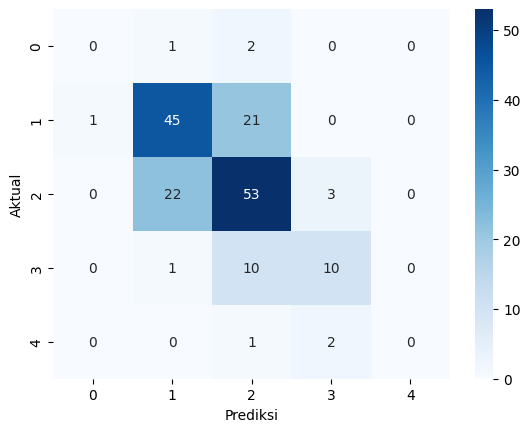


Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.65      0.67      0.66        67
           6       0.61      0.68      0.64        78
           7       0.67      0.48      0.56        21
           8       0.00      0.00      0.00         3

    accuracy                           0.63       172
   macro avg       0.39      0.37      0.37       172
weighted avg       0.61      0.63      0.62       172



In [45]:
# Inisialisasi dan melatih model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Memprediksi data validasi
y_pred_val = rf_model.predict(X_val_scaled)

# Evaluasi model dengan Akurasi dan Confusion Matrix
akurasi = accuracy_score(y_val, y_pred_val)
print(f"Akurasi Model: {akurasi:.4f}\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

print("\nClassification Report:\n", classification_report(y_val, y_pred_val, zero_division=0))

Pemilihan Model: Random Forest sangat efektif untuk menangani interaksi non-linear yang kompleks di antara fitur-fitur kimiawi, serta memiliki ketahanan yang baik terhadap overfitting.

Penanganan Imbalanced Data: Dataset kualitas anggur umumnya sangat tidak seimbang (kualitas menengah seperti 5 dan 6 jauh lebih banyak daripada kualitas sangat buruk atau sangat baik). Parameter balanced memberikan bobot penalti yang lebih besar jika model salah mengklasifikasikan kelas minoritas.

Evaluasi: Confusion Matrix memberikan visibilitas di mana model paling sering melakukan kesalahan prediksi antarkelas yang berdekatan.

5. Deployment Model pada Data Uji (Testing Data)

Pada tahap ini, dataset data_testing.csv dimuat. Penanganan data dilakukan persis seperti pada data pelatihan: kolom Id dipisahkan untuk keperluan pengumpulan hasil, nilai kosong (jika ada) diimputasi, dan matriks fitur disamakan secara dimensional. Normalisasi dilakukan dengan memanggil fungsi .transform() dari scaler yang sudah ada.

In [46]:
# Load dataset testing
df_test = pd.read_csv('data_testing.csv')

# Asumsikan df_test memiliki kolom 'Id'. Simpan id untuk format submission
test_ids = df_test['Id']

# Menghapus kolom Id agar fiturnya sama dengan data training saat di-scale
X_test = df_test.drop(columns=['Id'])

# Lakukan scaling yang sama menggunakan scaler yang sudah di-fit pada data training
X_test_scaled = scaler.transform(X_test)

# Prediksi menggunakan model yang sudah dilatih
prediksi_kualitas = rf_model.predict(X_test_scaled)

print("Prediksi sukses tanpa error!")

Prediksi sukses tanpa error!


Pencegahan Data Leakage (Kebocoran Data): Sangat krusial untuk hanya menggunakan scaler.transform() pada data uji, bukan fit_transform(). Hal ini memastikan data uji diskalakan menggunakan parameter rata-rata dan varians yang hanya dipelajari dari data pelatihan. Membiarkan model atau scaler "mempelajari" distribusi dari data uji adalah bentuk data leakage yang melanggar prinsip machine learning.

Konsistensi Dimensional: Menghapus kolom Id pada tahap ini menyelaraskan bentuk matriks fitur data uji dengan data latih, sehingga model dapat menjalankan prediksi (rf_model.predict) tanpa mengalami error akibat perbedaan jumlah fitur.

6. Ekspor Hasil Prediksi

Array hasil prediksi kualitas anggur digabungkan kembali dengan array Id yang sebelumnya disimpan. Keduanya dibentuk menjadi satu DataFrame baru dan diekspor ke dalam format CSV dengan membuang nomor indeks bawaan pandas (index=False).

In [47]:
# Membuat dataframe untuk hasil akhir
hasil_akhir = pd.DataFrame({
    'Id': test_ids,
    'Quality': prediksi_kualitas
})

nama_file = 'hasilprediksi_086.csv'
hasil_akhir.to_csv(nama_file, index=False)
print(f"File {nama_file} berhasil disimpan!")

File hasilprediksi_086.csv berhasil disimpan!


Langkah ini memenuhi syarat teknis pengumpulan ujian, di mana file luaran harus murni berupa dua kolom terstruktur (Id dan Quality) agar sistem penilaian (grader) dapat membandingkan prediksi yang dibuat dengan kunci jawaban tanpa terganggu oleh format kolom tambahan.